回帰分析と分類

In [2]:
import pandas as pd
df = pd.read_excel('breast_cancer_clean.xlsx')
df

,type,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,0,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,0,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,0,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [3]:
from sklearn.model_selection import train_test_split

x = df.drop(['type'],axis = 1)
y = df['type']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size=0.7, test_size=0.3, random_state=0)

In [4]:
# 決定木による教師あり学習
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

DecisionTreeClassifier()

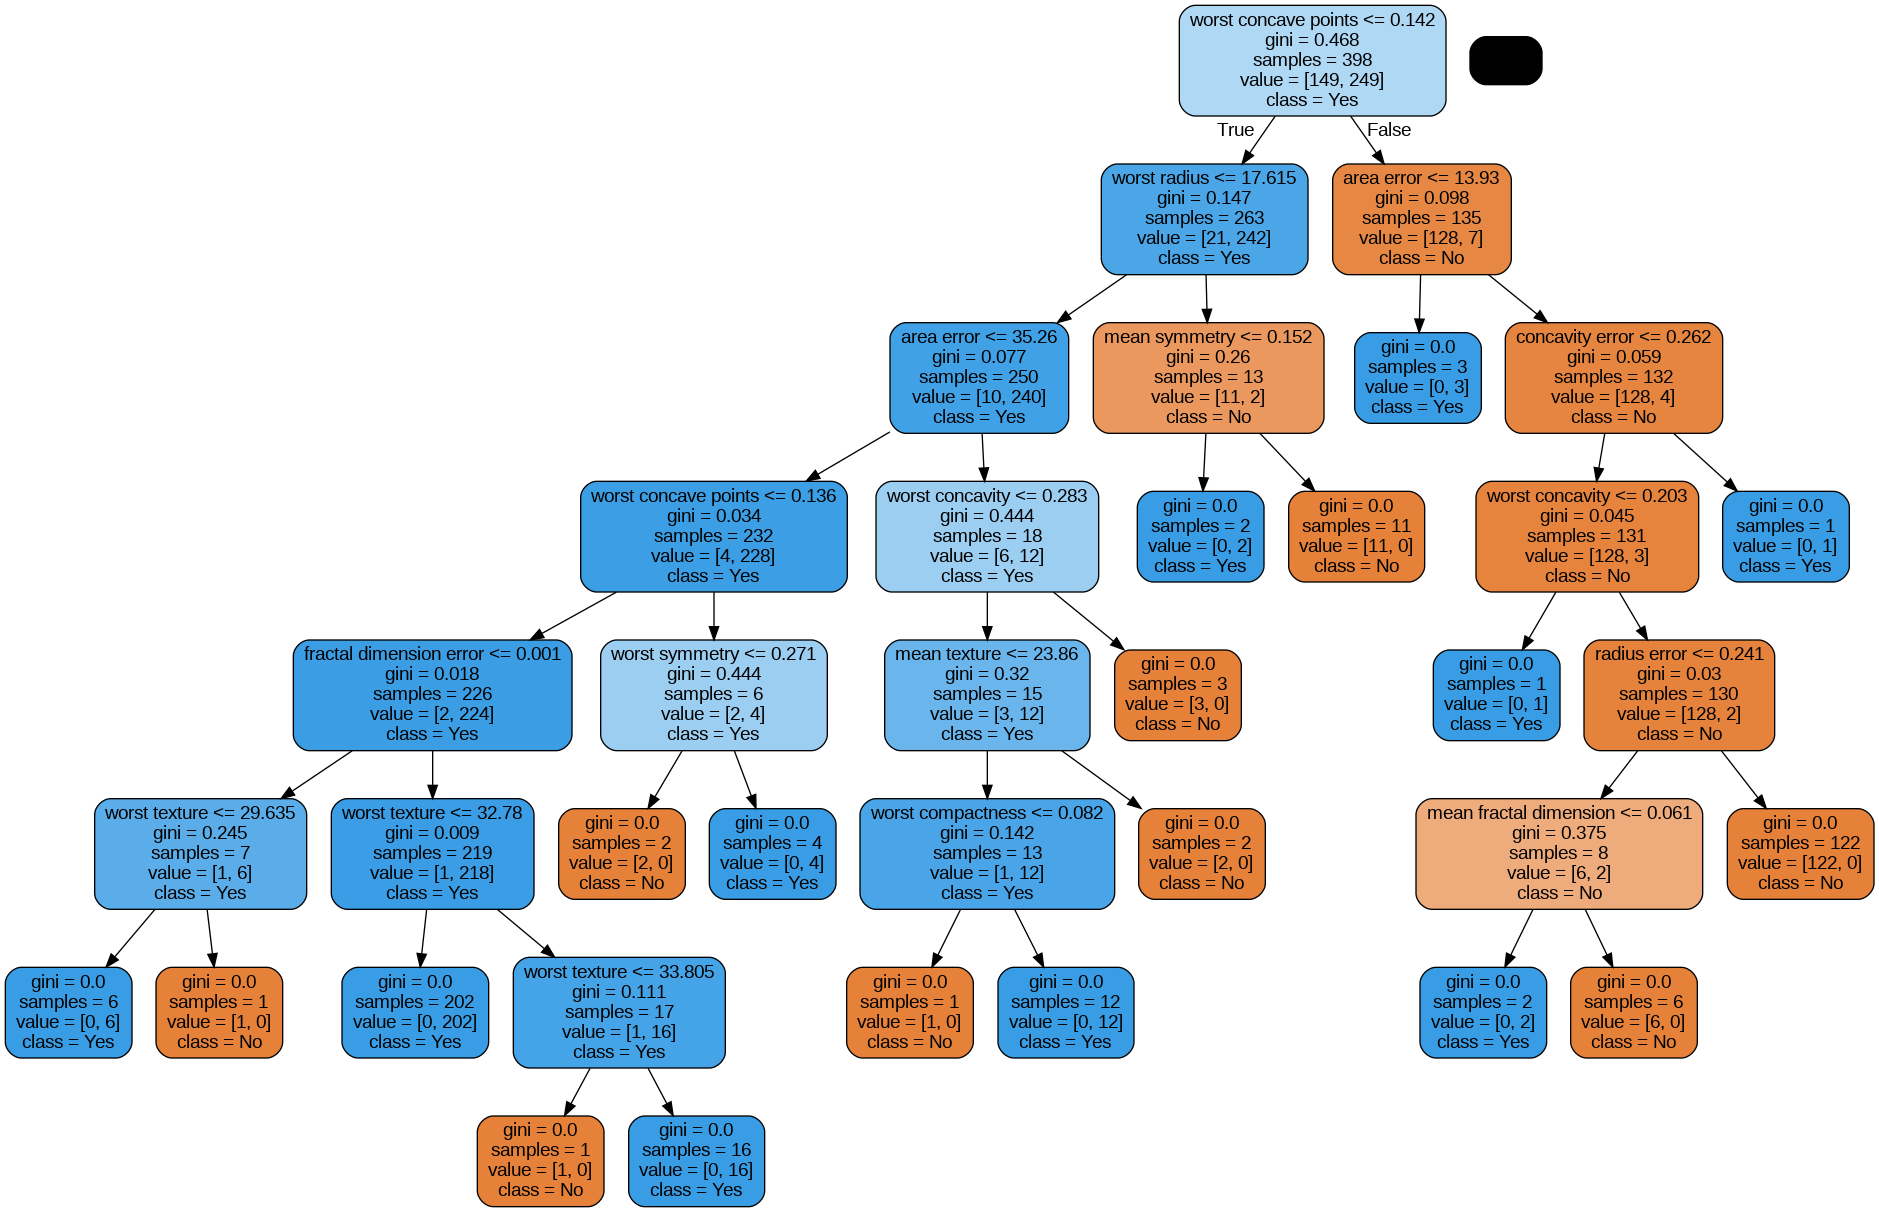

In [7]:
# 決定木の可視化
from sklearn.tree import export_graphviz
import pydotplus
from six import StringIO
from IPython.display import Image

dot_data = StringIO()
export_graphviz(model, out_file=dot_data,
                feature_names=x_train.columns,
                class_names=['No','Yes'],
                filled=True, rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

Text(0, 0.5, 'feature')

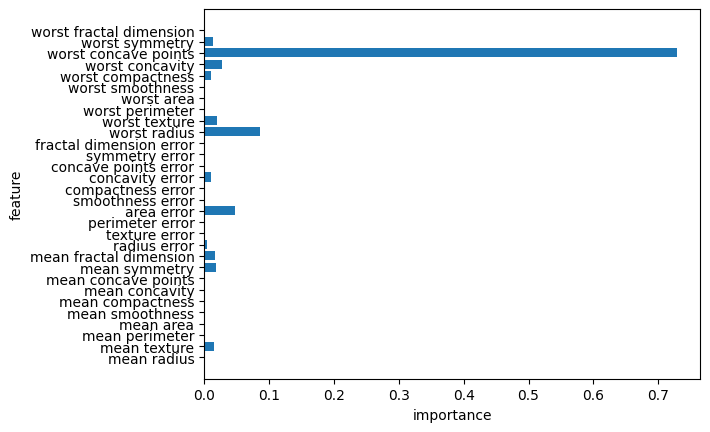

In [9]:
# 特徴量重要度の可視化
import numpy as np
from matplotlib import pyplot as plt

n_features = len(x_train.columns)
plt.barh(range(n_features), model.feature_importances_, align = 'center')
plt.yticks(np.arange(n_features), x_train.columns)
plt.xlabel("importance")
plt.ylabel("feature")

乳がんの悪性・良性を分類するうえで最悪値(worst concave points)の値が突出して有用であることが分かる。(逆に他の説明変数はほとんど役に立たない)

In [11]:
# 説明変数から推測される特定の人の乳がんの悪性・良性の推測の正解率
print('正解率(train):{:.3f}'.format(model.score(x_train, y_train)))
print('正解率(test);{:.3f}'.format(model.score(x_test, y_test)))

正解率(train):1.000
正解率(test);0.912


学習用データに対する正解率：100%　テストデータに対する正解率：91.2%

枝刈りあり(深さ3層まで)で行う決定木の分類精度を試す

In [12]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth = 3)
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

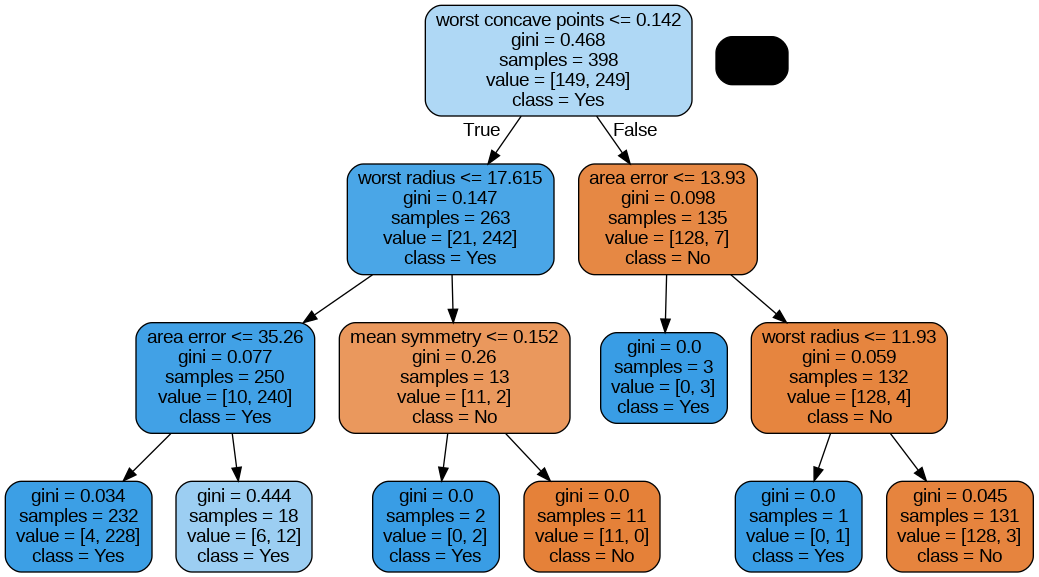

In [13]:
from sklearn.tree import export_graphviz
import pydotplus
from six import StringIO
from IPython.display import Image

dot_data = StringIO()
export_graphviz(model, out_file=dot_data,
                feature_names=x_train.columns,
                class_names=['No','Yes'],
                filled=True, rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [14]:
print('正解率(train):{:.3f}'.format(model.score(x_train, y_train)))
print('正解率(test);{:.3f}'.format(model.score(x_test, y_test)))

正解率(train):0.967
正解率(test);0.936


学習データの正解率は低下した一方で、テストデータの正解率は上がった

きちんと枝刈りを行うことで、決定木の汎化性能を改善できることが確認できた。決定木は過学習しやすいため、枝刈りは重要